# 🏠 California Housing Price Prediction
## A Complete Machine Learning Pipeline with Linear Regression

**Learning objectives:**
- Perform **Exploratory Data Analysis (EDA)** to understand your data before modeling
- Correctly **split data** into train / validation / test sets
- Apply **feature scaling** without data leakage
- Train and interpret a **Linear Regression** model

---
*Dataset*: California Housing (scikit-learn built-in, 20,640 census blocks)  
*Target*: `MedHouseVal` — Median house value in $100k units

## 📦 Import Libraries

Before writing any model code, we load every library we will need for the entire notebook:

| Library | Role |
|---------|------|
| `numpy` | Fast numerical arrays and math operations |
| `pandas` | Tabular data manipulation (DataFrames) |
| `matplotlib` / `seaborn` | Visualization |
| `sklearn` | Dataset loading, preprocessing, modeling, and metrics |

We also set a **global random seed** (`RANDOM_STATE = 42`) to ensure that every run produces identical results — a critical practice for reproducibility.

In [41]:
# ─── Import Libraries ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'DejaVu Sans',
})
PALETTE  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2',
            '#937860', '#DA8BC3', '#8C8C8C']
RANDOM_STATE = 42

print("✅ All libraries imported successfully.")
print(f"   NumPy    : {np.__version__}")
print(f"   Pandas   : {pd.__version__}")
print(f"   Sklearn  : {__import__('sklearn').__version__}")

✅ All libraries imported successfully.
   NumPy    : 2.0.2
   Pandas   : 2.2.2
   Sklearn  : 1.6.1


## 📂 Load & Inspect the Dataset

We load the **California Housing dataset** directly from scikit-learn.  
Each row represents one **census block group** — a neighbourhood-level geographic unit.

| Column | Description |
|--------|-------------|
| `MedInc` | Median income of block households (in tens of $1,000) |
| `HouseAge` | Median house age in the block |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Total block population |
| `AveOccup` | Average number of occupants per household |
| `Latitude` / `Longitude` | Geographic coordinates of the block |
| `MedHouseVal` ⭐ | **Target** — median house value in $100k |

We inspect the first rows, descriptive statistics, and confirm there are no missing values.

In [42]:
# ─── Load the Dataset ─────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape: {df.shape}  →  {df.shape[0]:,} census blocks, {df.shape[1]} columns")
print(f"\nFeature names : {housing.feature_names}")
print(f"Target name   : {housing.target_names[0]}")

print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Descriptive Statistics ---")
display(df.describe().round(3))

print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n✅ No missing values! (This is rare in real-world datasets.)")

DATASET OVERVIEW
Shape: (20640, 9)  →  20,640 census blocks, 9 columns

Feature names : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target name   : MedHouseVal

--- First 5 rows ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



--- Descriptive Statistics ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000



--- Missing Values ---
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

✅ No missing values! (This is rare in real-world datasets.)


## 📊 Feature Distributions (Histograms)

Before building any model, a good data scientist looks at the **shape of each feature's distribution**.  
This step reveals:

- **Skewness**: Is the data symmetric, or does it have a long tail? High skew can affect model assumptions.
- **Outliers**: Extreme values in `Population` or `AveOccup` suggest heavy tails.
- **Data quirks**: `HouseAge` has a spike at 52 because the census *capped* the value there.

Each subplot shows the mean (dashed black) and median (solid red) — when they differ widely, the distribution is skewed.

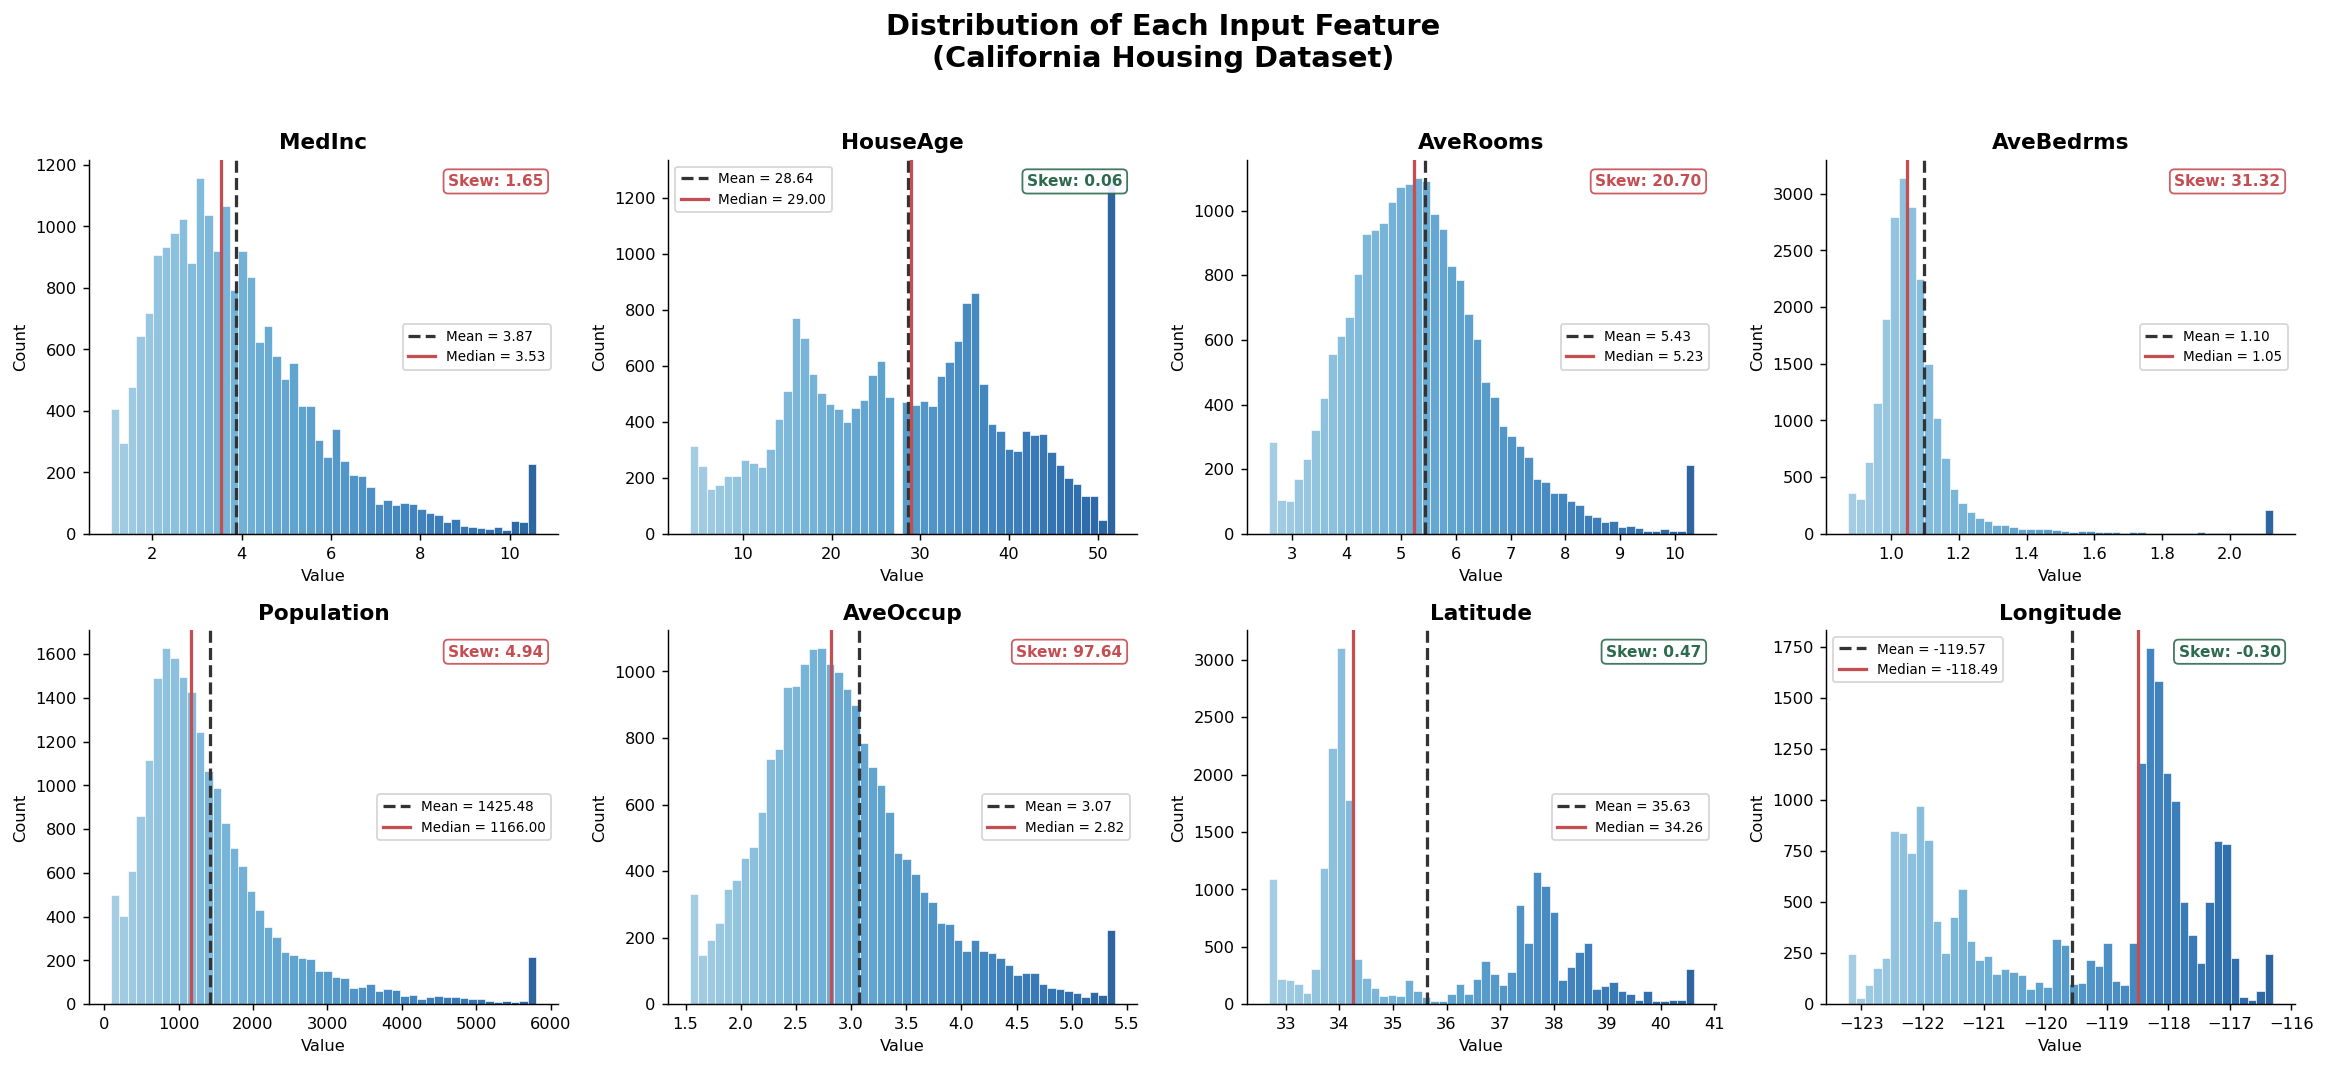

📊 Key observations:
   • AveRooms, Population, AveOccup are heavily right-skewed.
   • MedInc has moderate right skew — it is the most predictive feature.
   • HouseAge spikes at 52 due to census data capping.


In [43]:
# ─── Feature Distributions (Histograms) ───────────────────────────────
feature_names = housing.feature_names

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution of Each Input Feature\n(California Housing Dataset)',
             fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(feature_names):
    ax = axes[i // 4][i % 4]
    data = df[col]

    # Clip extreme outliers for display (p1–p99)
    p1, p99 = np.percentile(data, [1, 99])
    plot_data = data.clip(p1, p99)

    n, bins, patches = ax.hist(plot_data, bins=50, color=PALETTE[i],
                                edgecolor='white', linewidth=0.4, alpha=0.85)

    # Color bars by value for visual depth
    norm = plt.Normalize(bins[:-1].min(), bins[:-1].max())
    for patch, left_edge in zip(patches, bins[:-1]):
        patch.set_facecolor(plt.cm.Blues(0.4 + 0.5 * norm(left_edge)))

    ax.axvline(data.mean(),   color='#333333', linestyle='--', linewidth=1.8,
               label=f'Mean = {data.mean():.2f}')
    ax.axvline(data.median(), color='#C44E52', linestyle='-',  linewidth=1.8,
               label=f'Median = {data.median():.2f}')

    ax.set_title(col, fontsize=12, fontweight='bold', pad=6)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Count',  fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.8)

    skew_val = data.skew()
    skew_color = '#C44E52' if abs(skew_val) > 1 else '#2d6a4f'
    ax.text(0.97, 0.93, f'Skew: {skew_val:.2f}',
            transform=ax.transAxes, fontsize=8.5, color=skew_color,
            ha='right', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=skew_color, alpha=0.9))

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Key observations:")
print("   • AveRooms, Population, AveOccup are heavily right-skewed.")
print("   • MedInc has moderate right skew — it is the most predictive feature.")
print("   • HouseAge spikes at 52 due to census data capping.")

## 🔥 Correlation Heatmap

**Correlation** measures the linear relationship between two variables, ranging from –1 (perfect negative) to +1 (perfect positive).

This cell shows two complementary views:
1. **Left** — the full correlation matrix (lower triangle only, since it's symmetric)
2. **Right** — each feature's correlation with the **target** `MedHouseVal`, sorted from weakest to strongest

Key things to look for:
- **High target correlation** → feature is a strong linear predictor
- **High inter-feature correlation** → *multicollinearity*, which can inflate coefficient variance in Linear Regression

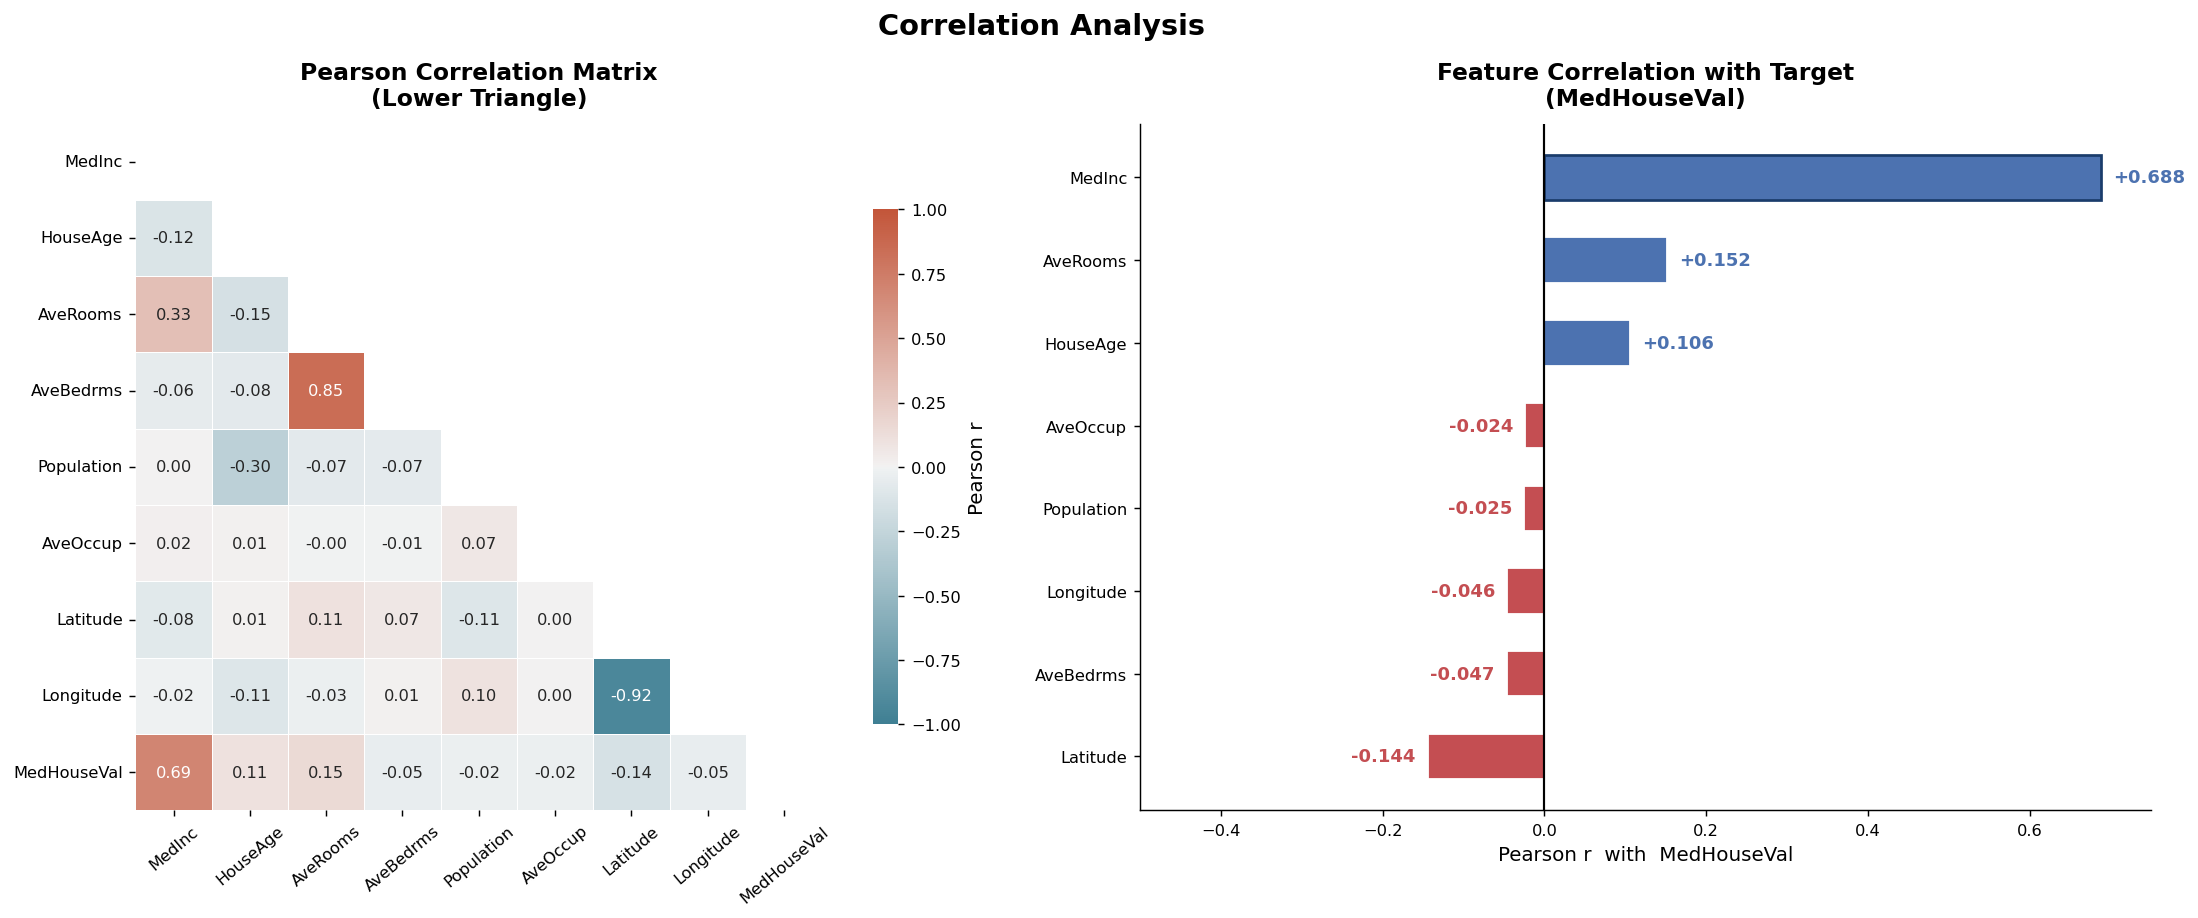

🔍 Key findings:
   Strongest positive predictor : MedInc          (r = 0.688)
   Strongest negative predictor : Latitude         (r = -0.144)
   Highest inter-feature corr   : AveRooms–AveBedrms (r = 0.848) ← multicollinearity warning!


In [44]:
# ─── Correlation Heatmap ─────────────────────────────────────────────
corr = df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Analysis', fontsize=16, fontweight='bold')

# ── Left: Full correlation heatmap ───────────────────────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

hm = sns.heatmap(corr,
            ax=axes[0],
            annot=True, fmt='.2f', annot_kws={'size': 9},
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            mask=mask,
            linewidths=0.5, linecolor='white',
            square=True,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
axes[0].set_title('Pearson Correlation Matrix\n(Lower Triangle)', fontsize=13,
                  fontweight='bold', pad=10)
axes[0].tick_params(axis='x', rotation=40, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

# ── Right: Target correlation bar chart ──────────────────────────────────────
target_corr = corr['MedHouseVal'].drop('MedHouseVal').sort_values()
bar_colors  = ['#C44E52' if v < 0 else '#4C72B0' for v in target_corr]

bars = axes[1].barh(target_corr.index, target_corr.values,
                    color=bar_colors, edgecolor='white', height=0.55)
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].set_xlabel('Pearson r  with  MedHouseVal', fontsize=11)
axes[1].set_title('Feature Correlation with Target\n(MedHouseVal)', fontsize=13,
                  fontweight='bold', pad=10)
axes[1].set_xlim(-0.5, 0.75)

for bar, val in zip(bars, target_corr.values):
    offset = 0.015 if val >= 0 else -0.015
    ha     = 'left'  if val >= 0 else 'right'
    axes[1].text(val + offset, bar.get_y() + bar.get_height() / 2,
                 f'{val:+.3f}', va='center', ha=ha,
                 fontsize=10, fontweight='bold',
                 color='#C44E52' if val < 0 else '#4C72B0')

# Add a subtle background to highlight the top predictor
axes[1].barh('MedInc', target_corr['MedInc'], color='#4C72B0',
             edgecolor='#1a3c6b', height=0.55, linewidth=1.5)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔍 Key findings:")
print(f"   Strongest positive predictor : MedInc          (r = {corr.loc['MedInc','MedHouseVal']:.3f})")
print(f"   Strongest negative predictor : Latitude         (r = {corr.loc['Latitude','MedHouseVal']:.3f})")
print(f"   Highest inter-feature corr   : AveRooms–AveBedrms (r = {corr.loc['AveRooms','AveBedrms']:.3f}) ← multicollinearity warning!")

## 🌍 Target Variable Analysis & Key Relationships

Before modeling, we study the **target variable** (`MedHouseVal`) in depth:

1. **Distribution** — Is it skewed? Are there outliers or censoring effects?
2. **Scatter plots** — How does each key feature relate to the target? Is the relationship linear?
3. **Geographic map** — Where are the expensive homes located? This visual alone reveals powerful spatial patterns that simple linear features can only partially capture.

> 📍 Note the hard ceiling at 5.0 ($500k) in the histogram — a **censoring artifact** from how the census data was collected.

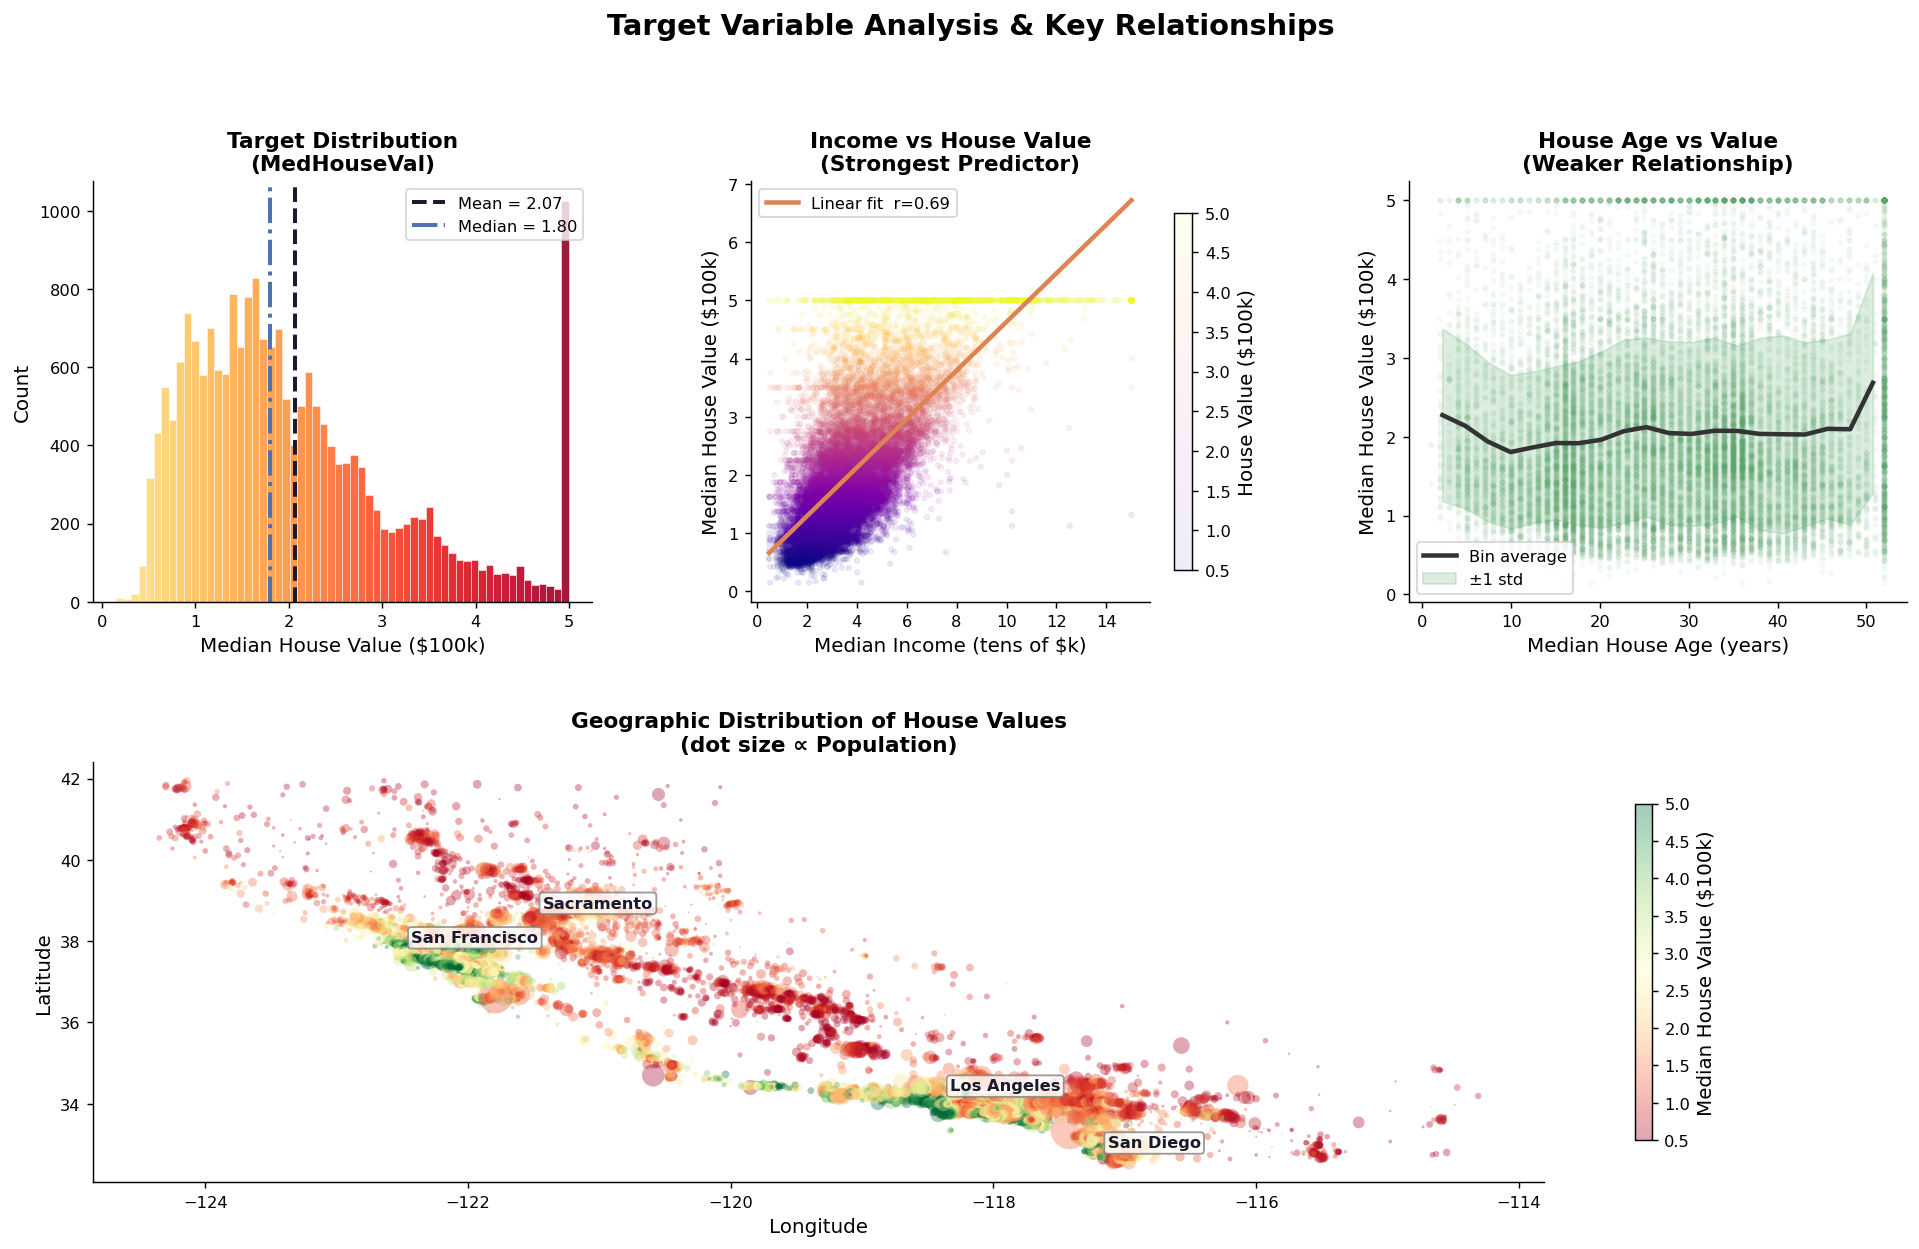

📍 Key insight: Coastal regions (SF Bay Area, LA, San Diego) have
   systematically higher house values — a spatial pattern only
   partially captured by linear latitude/longitude features.


In [45]:
# ─── Target Distribution and Key Relationships ───────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Target Variable Analysis & Key Relationships', fontsize=16,
             fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# ── Top-left: Target histogram ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts, bins, patches = ax1.hist(df['MedHouseVal'], bins=60,
                                  edgecolor='white', linewidth=0.3, alpha=0.9)
norm = plt.Normalize(bins[:-1].min(), bins[:-1].max())
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(plt.cm.YlOrRd(0.2 + 0.75 * norm(left)))

ax1.axvline(df['MedHouseVal'].mean(),   color='#1a1a2e', linestyle='--', lw=2.2,
            label=f"Mean = {df['MedHouseVal'].mean():.2f}")
ax1.axvline(df['MedHouseVal'].median(), color='#4C72B0', linestyle='-.',  lw=2.2,
            label=f"Median = {df['MedHouseVal'].median():.2f}")
ax1.set_xlabel('Median House Value ($100k)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Target Distribution\n(MedHouseVal)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.annotate('← Censored\n   at $500k', xy=(5.0, 1200), xytext=(3.8, 2200),
             fontsize=8.5, color='#C44E52', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.5))

# ── Top-middle: Income vs Value scatter ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sc = ax2.scatter(df['MedInc'], df['MedHouseVal'],
                 alpha=0.07, s=7,
                 c=df['MedHouseVal'], cmap='plasma', vmin=0.5, vmax=5)
plt.colorbar(sc, ax=ax2, label='House Value ($100k)', shrink=0.85)
m, b = np.polyfit(df['MedInc'], df['MedHouseVal'], 1)
x_line = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 100)
ax2.plot(x_line, m * x_line + b, '#DD8452', lw=2.5, label=f'Linear fit  r={corr.loc["MedInc","MedHouseVal"]:.2f}')
ax2.set_xlabel('Median Income (tens of $k)', fontsize=11)
ax2.set_ylabel('Median House Value ($100k)', fontsize=11)
ax2.set_title('Income vs House Value\n(Strongest Predictor)', fontsize=12, fontweight='bold')
ax2.legend()

# ── Top-right: House Age vs Value ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
# Bin by house age for clarity
age_bins = pd.cut(df['HouseAge'], bins=20)
age_means = df.groupby(age_bins, observed=True)['MedHouseVal'].agg(['mean', 'std'])
age_centers = [iv.mid for iv in age_means.index]
ax3.scatter(df['HouseAge'], df['MedHouseVal'], alpha=0.04, s=6, color='#55A868')
ax3.plot(age_centers, age_means['mean'], color='#333333', lw=2.5,
         label='Bin average', zorder=5)
ax3.fill_between(age_centers,
                 age_means['mean'] - age_means['std'],
                 age_means['mean'] + age_means['std'],
                 alpha=0.2, color='#55A868', label='±1 std')
ax3.set_xlabel('Median House Age (years)', fontsize=11)
ax3.set_ylabel('Median House Value ($100k)', fontsize=11)
ax3.set_title('House Age vs Value\n(Weaker Relationship)', fontsize=12, fontweight='bold')
ax3.legend()

# ── Bottom: Geographic map of house values ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
sc2 = ax4.scatter(df['Longitude'], df['Latitude'],
                  c=df['MedHouseVal'], cmap='RdYlGn',
                  alpha=0.35, s=df['Population'] / 80,
                  vmin=0.5, vmax=5.0, linewidths=0)
cbar = plt.colorbar(sc2, ax=ax4, label='Median House Value ($100k)', shrink=0.8)
ax4.set_xlabel('Longitude', fontsize=11)
ax4.set_ylabel('Latitude', fontsize=11)
ax4.set_title('Geographic Distribution of House Values\n(dot size ∝ Population)',
              fontsize=12, fontweight='bold')

for city, lon, lat in [('San Diego', -117.2, 32.7),
                        ('Los Angeles', -118.4, 34.1),
                        ('San Francisco', -122.5, 37.75),
                        ('Sacramento', -121.5, 38.6)]:
    ax4.annotate(city, (lon, lat), fontsize=9, fontweight='bold', color='#1a1a2e',
                 xytext=(5, 5), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                           edgecolor='gray', alpha=0.8))

plt.savefig('target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("📍 Key insight: Coastal regions (SF Bay Area, LA, San Diego) have")
print("   systematically higher house values — a spatial pattern only")
print("   partially captured by linear latitude/longitude features.")

## ✂️ Train / Validation / Test Split & Feature Scaling

### Why three sets?
| Set | Purpose | Used when |
|-----|---------|-----------|
| **Train** (70%) | Fit model parameters | During training |
| **Validation** (15%) | Tune hyperparameters, compare models | Repeatedly during development |
| **Test** (15%) | Final unbiased evaluation | **Only once**, at the very end |

> ⚠️ Using the test set more than once causes **data leakage** — you'd be optimizing for test performance without realizing it.

### Why scale features?
Linear Regression's coefficients are directly comparable **only if** all features live on the same scale. `Population` ranges in the thousands while `AveBedrms` is near 1 — without scaling, the raw coefficients are misleading.

`StandardScaler` transforms each feature to **mean = 0, std = 1**.  
🔑 **Critical rule**: fit the scaler *only* on training data, then apply the same transformation to val/test. Otherwise you leak test-set statistics into training.

DATASET SPLIT SUMMARY
  Total samples   : 20,640
  Training set    : 14,448  (70%)
  Validation set  : 3,096   (15%)
  Test set        : 3,096   (15%)

✅ Scaler fitted on training data only.
   Training mean (per feature): [ 3.88000e+00  2.85800e+01  5.44000e+00  1.10000e+00  1.42793e+03
  3.12000e+00  3.56500e+01 -1.19580e+02]
   Training std  (per feature): [1.90000e+00 1.26100e+01 2.45000e+00 4.50000e-01 1.14019e+03 1.23700e+01
 2.14000e+00 2.00000e+00]


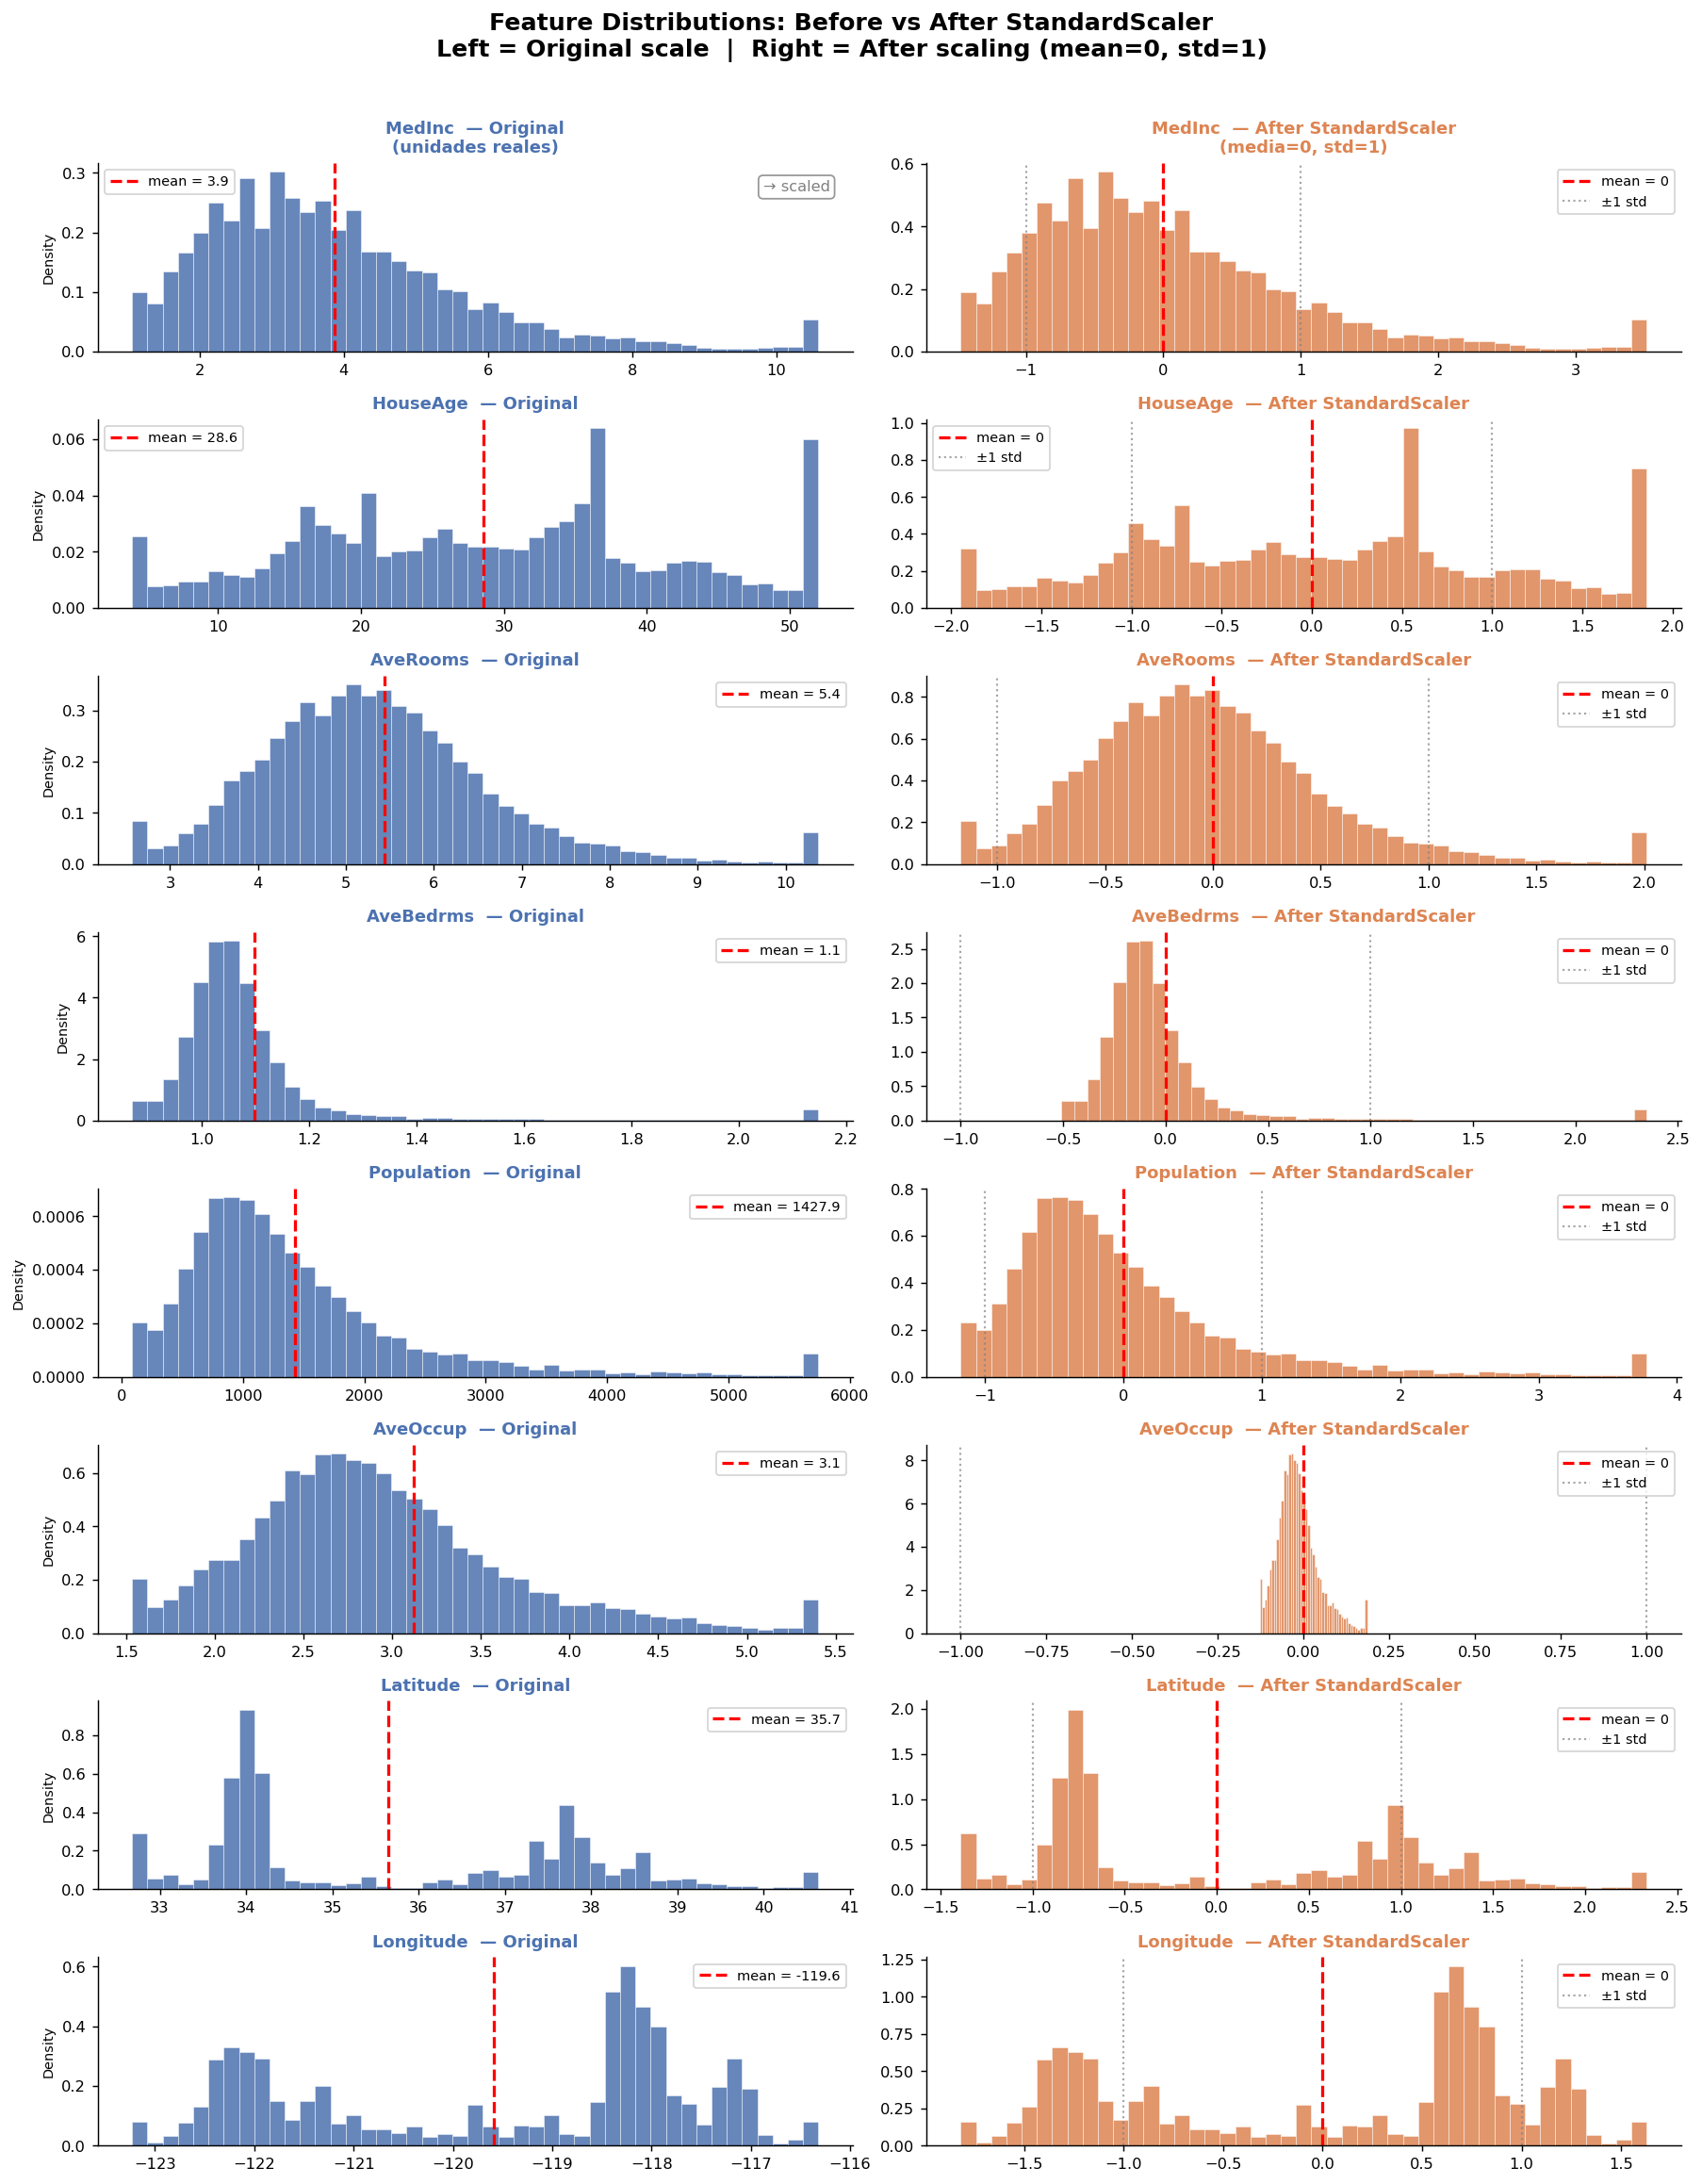


💡 Qué hace StandardScaler a cada feature:
   Feature       Mean (orig)   Std (orig)  →   Mean (scaled)  Std (scaled)
   ----------------------------------------------------------------------
   MedInc               3.88         1.90  →         -0.0000        1.0000
   HouseAge            28.58        12.61  →         -0.0000        1.0000
   AveRooms             5.44         2.45  →          0.0000        1.0000
   AveBedrms            1.10         0.45  →          0.0000        1.0000
   Population        1427.93      1140.19  →          0.0000        1.0000
   AveOccup             3.12        12.37  →          0.0000        1.0000
   Latitude            35.65         2.14  →         -0.0000        1.0000
   Longitude         -119.58         2.00  →          0.0000        1.0000


In [46]:
# ─── Train / Validation / Test Split + Feature Scaling ───────────────
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Step 1: 70% train, 30% temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
# Step 2: Split holdout 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print("=" * 48)
print("DATASET SPLIT SUMMARY")
print("=" * 48)
print(f"  Total samples   : {len(X):,}")
print(f"  Training set    : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Validation set  : {len(X_val):,}   ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test set        : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)")

# ── Feature Scaling (NO DATA LEAKAGE) ─────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform on train
X_val_s   = scaler.transform(X_val)         # transform only (no fit)
X_test_s  = scaler.transform(X_test)        # transform only (no fit)

print(f"\n✅ Scaler fitted on training data only.")
print(f"   Training mean (per feature): {scaler.mean_.round(2)}")
print(f"   Training std  (per feature): {scaler.scale_.round(2)}")

# ── Visualization: Before vs After Scaling ────────────────────────────────────
# KEY FIX: each feature gets its own pair of axes (left=original, right=scaled)
# so the different x-scales don't crush each other.

X_train_scaled_df = pd.DataFrame(X_train_s, columns=X.columns)
features = list(X.columns)
n = len(features)   # 8 features

fig, axes = plt.subplots(n, 2, figsize=(14, n * 2.2))
fig.suptitle(
    'Feature Distributions: Before vs After StandardScaler\n'
    'Left = Original scale  |  Right = After scaling (mean=0, std=1)',
    fontsize=14, fontweight='bold', y=1.01
)

COLOR_ORIG   = '#4C72B0'
COLOR_SCALED = '#DD8452'

for i, col in enumerate(features):
    ax_orig   = axes[i, 0]
    ax_scaled = axes[i, 1]

    # --- clip extreme outliers for display only (p1–p99) ---
    p1, p99 = np.percentile(X_train[col], [1, 99])
    orig_data = X_train[col].clip(p1, p99)

    p1s, p99s = np.percentile(X_train_scaled_df[col], [1, 99])
    scaled_data = X_train_scaled_df[col].clip(p1s, p99s)

    # --- plot original ---
    ax_orig.hist(orig_data, bins=45, color=COLOR_ORIG,
                 edgecolor='white', linewidth=0.3, density=True, alpha=0.85)
    ax_orig.axvline(X_train[col].mean(), color='red', lw=1.8,
                    linestyle='--', label=f'mean = {X_train[col].mean():.1f}')
    ax_orig.set_title(f'{col}  — Original', fontsize=10, fontweight='bold',
                      color=COLOR_ORIG)
    ax_orig.legend(fontsize=8)
    ax_orig.set_ylabel('Density', fontsize=8)

    # --- plot scaled ---
    ax_scaled.hist(scaled_data, bins=45, color=COLOR_SCALED,
                   edgecolor='white', linewidth=0.3, density=True, alpha=0.85)
    ax_scaled.axvline(0, color='red', lw=1.8, linestyle='--', label='mean = 0')
    ax_scaled.axvline(-1, color='gray', lw=1.2, linestyle=':', alpha=0.7, label='±1 std')
    ax_scaled.axvline( 1, color='gray', lw=1.2, linestyle=':', alpha=0.7)
    ax_scaled.set_title(f'{col}  — After StandardScaler', fontsize=10,
                        fontweight='bold', color=COLOR_SCALED)
    ax_scaled.legend(fontsize=8)

    # add a subtle arrow annotation on the first feature to explain the concept
    if i == 0:
        ax_orig.text(0.97, 0.85, '→ scaled', transform=ax_orig.transAxes,
                     fontsize=9, ha='right', color='gray',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                               edgecolor='gray', alpha=0.8))

# label the two columns at the top
axes[0, 0].set_title(f'{features[0]}  — Original\n(unidades reales)',
                     fontsize=10, fontweight='bold', color=COLOR_ORIG)
axes[0, 1].set_title(f'{features[0]}  — After StandardScaler\n(media=0, std=1)',
                     fontsize=10, fontweight='bold', color=COLOR_SCALED)

plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Qué hace StandardScaler a cada feature:")
print(f"   {'Feature':<12} {'Mean (orig)':>12} {'Std (orig)':>12}  →  {'Mean (scaled)':>14} {'Std (scaled)':>13}")
print("   " + "-" * 70)
for col, mean_, std_ in zip(X.columns, scaler.mean_, scaler.scale_):
    scaled_col = X_train_scaled_df[col]
    print(f"   {col:<12} {mean_:>12.2f} {std_:>12.2f}  →  {scaled_col.mean():>14.4f} {scaled_col.std():>13.4f}")

## 🤖 Train the Linear Regression Model

**Linear Regression** finds the *hyperplane* that minimises the **sum of squared residuals**:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

Because we scaled the features first, the coefficients are **standardized** — they are directly comparable. A coefficient of `0.8` means "a 1-standard-deviation increase in this feature raises the predicted price by `0.8 × $100k = $80k`".

The **intercept** (β₀) equals the average house value in the training set (since scaled features have mean 0).

In [47]:
# ─── Train Linear Regression ─────────────────────────────────────────
model = LinearRegression()
model.fit(X_train_s, y_train)

coef_df = pd.DataFrame({
    'Feature'     : X.columns,
    'Coefficient' : model.coef_,
    'Abs_Coeff'   : np.abs(model.coef_),
    'Direction'   : ['▲ Positive' if c > 0 else '▼ Negative' for c in model.coef_]
}).sort_values('Abs_Coeff', ascending=False).reset_index(drop=True)

print("=" * 62)
print("LINEAR REGRESSION MODEL — LEARNED COEFFICIENTS (Standardized)")
print("=" * 62)
print(f"  Intercept (β₀): {model.intercept_:.4f}  ≈ average house value (in $100k)")
print()
print(coef_df.to_string(index=False))
print("\n📌 Interpretation example:")
print(f"   MedInc coefficient = {model.coef_[0]:.4f}")
print(f"   → A 1 std increase in MedInc raises predicted value by ~${model.coef_[0]*100:.0f}k")

LINEAR REGRESSION MODEL — LEARNED COEFFICIENTS (Standardized)
  Intercept (β₀): 2.0692  ≈ average house value (in $100k)

   Feature  Coefficient  Abs_Coeff  Direction
  Latitude    -0.893856   0.893856 ▼ Negative
 Longitude    -0.868617   0.868617 ▼ Negative
    MedInc     0.849222   0.849222 ▲ Positive
 AveBedrms     0.348410   0.348410 ▲ Positive
  AveRooms    -0.299558   0.299558 ▼ Negative
  HouseAge     0.122119   0.122119 ▲ Positive
  AveOccup    -0.041698   0.041698 ▼ Negative
Population    -0.000884   0.000884 ▼ Negative

📌 Interpretation example:
   MedInc coefficient = 0.8492
   → A 1 std increase in MedInc raises predicted value by ~$85k


## 📏 Evaluate on the Validation Set

Three complementary metrics tell the full story:

| Metric | Formula | Interpretation | Sensitive to outliers? |
|--------|---------|---------------|----------------------|
| **RMSE** | √mean((y − ŷ)²) | Average error in original units (penalises large errors heavily) | ✅ Yes |
| **MAE** | mean(|y − ŷ|) | Average absolute error — more robust | ❌ No |
| **R²** | 1 − SS_res/SS_tot | Fraction of variance explained (1 = perfect, 0 = predicts mean) | Moderate |

We also compute a **naive baseline** (always predict the training mean) to see how much our model actually helps.

In [48]:
# ─── Evaluate on Validation Set ──────────────────────────────────────
y_pred_val = model.predict(X_val_s)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae  = mean_absolute_error(y_val, y_pred_val)
r2   = r2_score(y_val, y_pred_val)
mse  = mean_squared_error(y_val, y_pred_val)

print("=" * 52)
print("MODEL PERFORMANCE — VALIDATION SET")
print("=" * 52)
print(f"  MSE  (Mean Squared Error)       : {mse:.4f}")
print(f"  RMSE (Root Mean Squared Error)  : {rmse:.4f}  →  ~${rmse*100:.0f}k average error")
print(f"  MAE  (Mean Absolute Error)      : {mae:.4f}  →  ~${mae*100:.0f}k average error")
print(f"  R²   (Coefficient of Det.)      : {r2:.4f}  →  model explains {r2*100:.1f}% of variance")
print()

# Naive baseline: always predict the training mean
baseline_pred = np.full_like(y_val, y_train.mean(), dtype=float)
baseline_r2   = r2_score(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))


MODEL PERFORMANCE — VALIDATION SET
  MSE  (Mean Squared Error)       : 0.5409
  RMSE (Root Mean Squared Error)  : 0.7354  →  ~$74k average error
  MAE  (Mean Absolute Error)      : 0.5335  →  ~$53k average error
  R²   (Coefficient of Det.)      : 0.5848  →  model explains 58.5% of variance



## 🎯 Actual vs. Predicted Plots

Two charts to visualize prediction quality:

1. **Scatter plot (left)** — Each dot is one census block. Perfect predictions land on the diagonal red line. Points are colored by error magnitude (green = close, red = far). The shaded band shows the ±RMSE zone.

2. **Error distribution (right)** — The histogram of `(actual − predicted)` errors. For a well-specified linear model, this should look roughly **bell-shaped and centred at zero**. A fitted normal curve helps us judge symmetry.

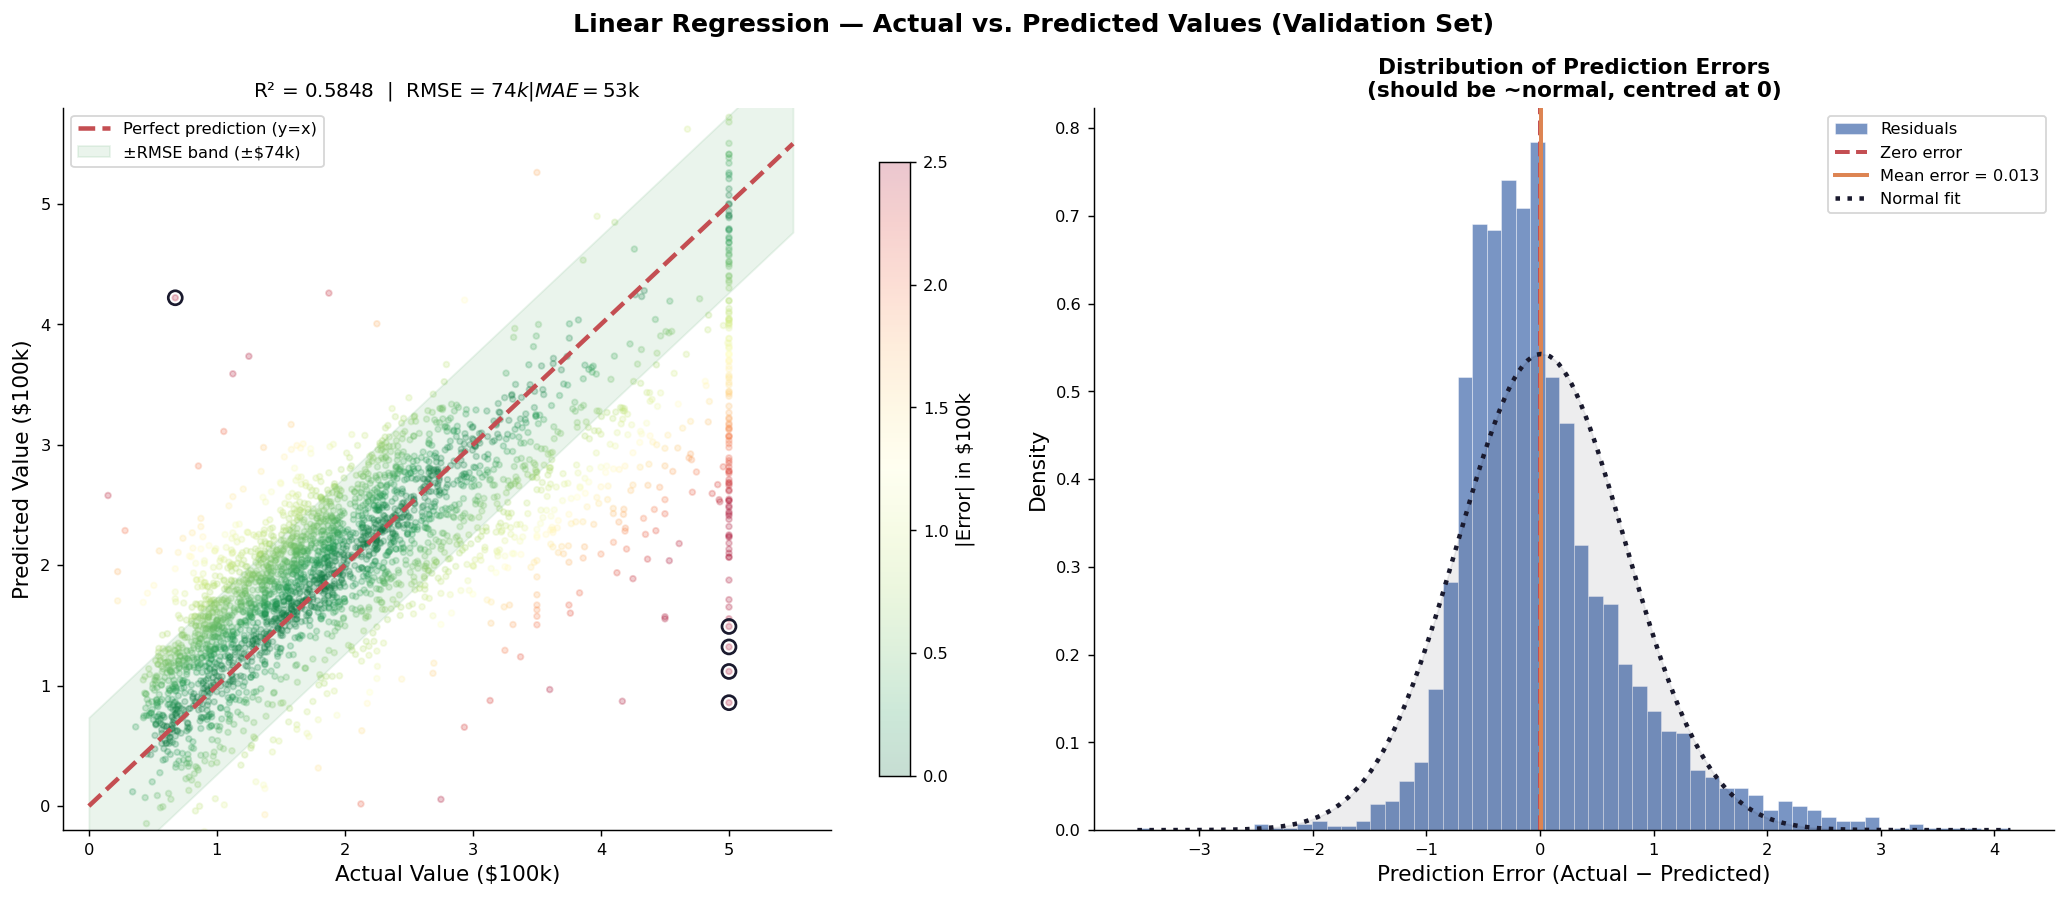

📊 The error distribution is roughly bell-shaped, centred near 0.
   A slight right skew suggests the model occasionally under-predicts
   the highest-value homes (>$400k).


In [49]:
# ─── Actual vs Predicted Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Linear Regression — Actual vs. Predicted Values (Validation Set)',
             fontsize=14, fontweight='bold')

# ── Left: Scatter with error-magnitude coloring ───────────────────────────────
ax1 = axes[0]
sc = ax1.scatter(y_val, y_pred_val,
                 alpha=0.22, s=10,
                 c=np.abs(y_val.values - y_pred_val),
                 cmap='RdYlGn_r', vmin=0, vmax=2.5)
plt.colorbar(sc, ax=ax1, label='|Error| in $100k', shrink=0.85)

# Perfect prediction line
ax1.plot([0, 5.5], [0, 5.5], color='#C44E52', lw=2.5,
         linestyle='--', label='Perfect prediction (y=x)', zorder=5)

# ±RMSE shaded band
x_range = np.linspace(0, 5.5, 100)
ax1.fill_between(x_range, x_range - rmse, x_range + rmse,
                 alpha=0.12, color='#55A868',
                 label=f'±RMSE band (±${rmse*100:.0f}k)')

ax1.set_xlabel('Actual Value ($100k)', fontsize=12)
ax1.set_ylabel('Predicted Value ($100k)', fontsize=12)
ax1.set_title(f'R² = {r2:.4f}  |  RMSE = ${rmse*100:.0f}k  |  MAE = ${mae*100:.0f}k',
              fontsize=11)
ax1.legend()
ax1.set_xlim(-0.2, 5.8)
ax1.set_ylim(-0.2, 5.8)

# Annotate a few extreme mis-predictions
errors_abs = np.abs(y_val.values - y_pred_val)
top_err_idx = np.argsort(errors_abs)[-5:]
for idx in top_err_idx:
    ax1.scatter(y_val.values[idx], y_pred_val[idx],
                s=60, edgecolors='#1a1a2e', facecolors='none', linewidths=1.5, zorder=6)

# ── Right: Error distribution ─────────────────────────────────────────────────
ax2 = axes[1]
errors = y_val.values - y_pred_val
ax2.hist(errors, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.3,
         density=True, alpha=0.75, label='Residuals')
ax2.axvline(0,             color='#C44E52',  linestyle='--', lw=2.2, label='Zero error')
ax2.axvline(errors.mean(), color='#DD8452', linestyle='-',  lw=2.2,
            label=f'Mean error = {errors.mean():.3f}')

# Overlay a normal distribution
x_err = np.linspace(errors.min(), errors.max(), 200)
ax2.plot(x_err, sp_stats.norm.pdf(x_err, errors.mean(), errors.std()),
         '#1a1a2e', lw=2.5, linestyle=':', label='Normal fit')
ax2.fill_between(x_err, sp_stats.norm.pdf(x_err, errors.mean(), errors.std()),
                 alpha=0.08, color='#1a1a2e')

ax2.set_xlabel('Prediction Error (Actual − Predicted)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution of Prediction Errors\n(should be ~normal, centred at 0)',
              fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 The error distribution is roughly bell-shaped, centred near 0.")
print("   A slight right skew suggests the model occasionally under-predicts")
print("   the highest-value homes (>$400k).")

## 🔄 Cross-Validation

A single train/val split can be **misleading** — performance might be particularly good or bad just because of which samples ended up in which set.

**k-Fold Cross-Validation** solves this:
1. Split the full data into *k* = 5 equal folds
2. Train on *k-1* folds, evaluate on the held-out fold
3. Repeat *k* times, rotating the held-out fold
4. Average the *k* scores for a **more robust estimate**

> 🔑 We wrap scaler + model in a `Pipeline` so that the scaler is **refitted from scratch on each fold's training data** — preventing data leakage inside CV.

5-FOLD CROSS-VALIDATION RESULTS  (Pipeline: Scaler + LinearReg)
  Fold R² scores   : [0.5487 0.4682 0.5508 0.537  0.6605]
  Mean R²          : 0.5530 ± 0.0617

  Fold RMSE scores : [0.6963 0.789  0.8039 0.737  0.7033]
  Mean RMSE        : 0.7459 ± 0.0437  ($75k ± $4k)


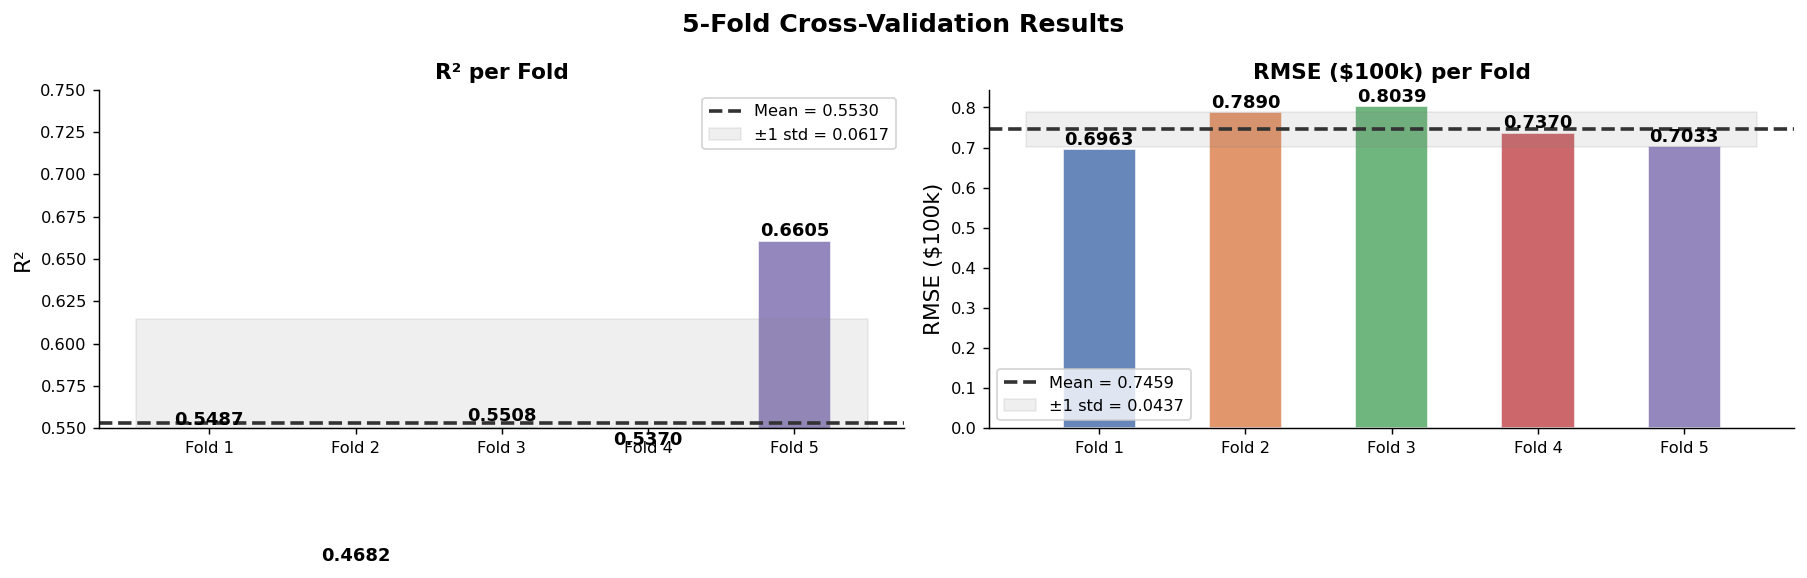


✅ Low std across folds (0.0617) means the model is stable and not
   overly sensitive to which samples land in train vs. validation.


In [50]:
# ─── Cross-Validation ────────────────────────────────────────────────
# Pipeline ensures scaler is fitted fresh on each fold's training data
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

cv_r2   = cross_val_score(pipeline, X, y, cv=5, scoring='r2', n_jobs=-1)
cv_rmse = -cross_val_score(pipeline, X, y, cv=5,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)

print("=" * 62)
print("5-FOLD CROSS-VALIDATION RESULTS  (Pipeline: Scaler + LinearReg)")
print("=" * 62)
print(f"  Fold R² scores   : {np.round(cv_r2, 4)}")
print(f"  Mean R²          : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print()
print(f"  Fold RMSE scores : {np.round(cv_rmse, 4)}")
print(f"  Mean RMSE        : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}  "
      f"(${cv_rmse.mean()*100:.0f}k ± ${cv_rmse.std()*100:.0f}k)")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

folds  = [f'Fold {i+1}' for i in range(5)]
colors_fold = PALETTE[:5]

for ax, scores, label, unit in [
    (axes[0], cv_r2,   'R²',          ''),
    (axes[1], cv_rmse, 'RMSE ($100k)', ''),
]:
    bars = ax.bar(folds, scores, color=colors_fold, edgecolor='white', width=0.5,
                  alpha=0.85)
    ax.axhline(scores.mean(), color='#333333', linestyle='--', lw=2,
               label=f'Mean = {scores.mean():.4f}')
    ax.fill_between([-0.5, 4.5],
                    [scores.mean() - scores.std()] * 2,
                    [scores.mean() + scores.std()] * 2,
                    alpha=0.12, color='gray', label=f'±1 std = {scores.std():.4f}')
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} per Fold', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

axes[0].set_ylim(0.55, 0.75)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Low std across folds ({cv_r2.std():.4f}) means the model is stable and not")
print(f"   overly sensitive to which samples land in train vs. validation.")

## 📌 Feature Importance via Standardized Coefficients

Because we scaled all features to the **same standard deviation before training**, the model's coefficients are directly comparable — a larger absolute value means a stronger influence on the prediction.

Two views:
- **Left** — Absolute magnitude (importance ranking, regardless of direction)
- **Right** — Signed value (direction of the effect: positive = raises price, negative = lowers price)

> 💡 This is a unique advantage of Linear Regression: it is fully **interpretable**. More complex models (e.g. Random Forest, XGBoost) require separate importance calculations that are harder to interpret.

/tmp/ipython-input-2040664876.py:49: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2040664876.py:49: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2040664876.py:50: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-2040664876.py:50: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font

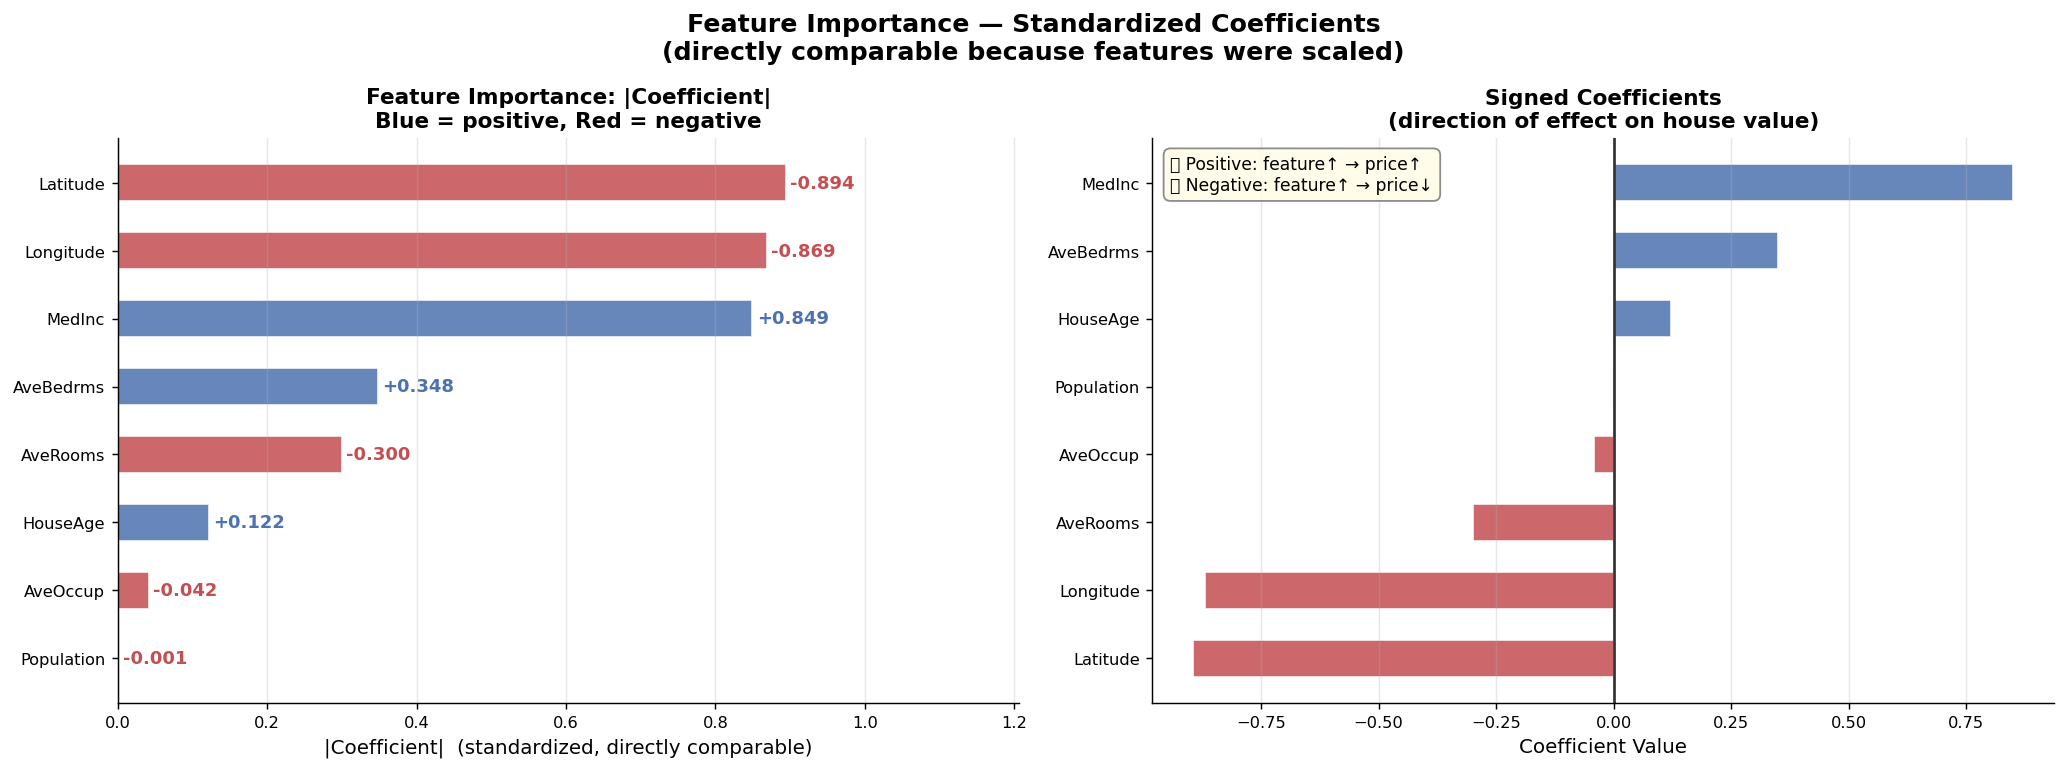


📊 Feature Importance Summary:
   Feature  Coefficient  AbsCoeff
  Latitude    -0.893856  0.893856
 Longitude    -0.868617  0.868617
    MedInc     0.849222  0.849222
 AveBedrms     0.348410  0.348410
  AveRooms    -0.299558  0.299558
  HouseAge     0.122119  0.122119
  AveOccup    -0.041698  0.041698
Population    -0.000884  0.000884

💡 MedInc dominates — confirming our EDA finding.
   AveOccup is negative: more occupants per household → lower predicted price.
   Lat/Long carry moderate importance, capturing coastal location effects linearly.


In [51]:
# ─── Feature Importance Visualization ───────────────────────────────
importance_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_,
    'AbsCoeff'   : np.abs(model.coef_)
}).sort_values('AbsCoeff', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Standardized Coefficients\n'
             '(directly comparable because features were scaled)',
             fontsize=14, fontweight='bold')

def coef_color(val):
    return '#C44E52' if val < 0 else '#4C72B0'

# ── Left: |Coefficient| ──────────────────────────────────────────────────────
bar_colors = [coef_color(c) for c in importance_df['Coefficient']]
bars = axes[0].barh(importance_df['Feature'], importance_df['AbsCoeff'],
                    color=bar_colors, edgecolor='white', height=0.55, alpha=0.85)
axes[0].set_xlabel('|Coefficient|  (standardized, directly comparable)', fontsize=11)
axes[0].set_title('Feature Importance: |Coefficient|\nBlue = positive, Red = negative',
                  fontsize=12, fontweight='bold')

for bar, coef in zip(bars, importance_df['Coefficient']):
    label = f'+{coef:.3f}' if coef > 0 else f'{coef:.3f}'
    axes[0].text(bar.get_width() + 0.006,
                 bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=10, fontweight='bold',
                 color=coef_color(coef))
axes[0].set_xlim(0, importance_df['AbsCoeff'].max() * 1.35)
axes[0].grid(axis='x', alpha=0.3)

# ── Right: Signed coefficients ────────────────────────────────────────────────
imp_signed  = importance_df.sort_values('Coefficient')
axes[1].barh(imp_signed['Feature'], imp_signed['Coefficient'],
             color=[coef_color(c) for c in imp_signed['Coefficient']],
             edgecolor='white', height=0.55, alpha=0.85)
axes[1].axvline(0, color='#333333', linewidth=1.5)
axes[1].set_xlabel('Coefficient Value', fontsize=11)
axes[1].set_title('Signed Coefficients\n(direction of effect on house value)',
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].text(0.02, 0.97,
             '🔵 Positive: feature↑ → price↑\n🔴 Negative: feature↑ → price↓',
             transform=axes[1].transAxes, fontsize=9.5, va='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#fffde7',
                       edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Feature Importance Summary:")
print(importance_df[['Feature','Coefficient','AbsCoeff']]
      .sort_values('AbsCoeff', ascending=False).to_string(index=False))
print("\n💡 MedInc dominates — confirming our EDA finding.")
print("   AveOccup is negative: more occupants per household → lower predicted price.")
print("   Lat/Long carry moderate importance, capturing coastal location effects linearly.")